# 📉 Telco Customer Churn — Prediction & Analysis

**Goal:** Predict which customers are likely to churn (cancel their telecom service) and surface the business drivers behind churn, so that retention teams can act before customers leave.

**Dataset:** [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 customers, 21 attributes (demographics, account info, subscribed services, billing).

**Approach**
1. Clean & prepare the raw data
2. Explore churn patterns visually (EDA)
3. Engineer features and handle class imbalance (SMOTE)
4. Train & tune 6 classification models
5. Compare models on Accuracy, Precision, Recall, F1 and ROC-AUC
6. Identify the strongest churn drivers

---

### Table of Contents
1. [Setup](#1.-Setup)
2. [Load the Data](#2.-Load-the-Data)
3. [Data Cleaning](#3.-Data-Cleaning)
4. [Exploratory Data Analysis](#4.-Exploratory-Data-Analysis)
5. [Feature Engineering](#5.-Feature-Engineering)
6. [Train / Test Split & Class Balancing](#6.-Train-/-Test-Split-&-Class-Balancing)
7. [Model Training & Hyperparameter Tuning](#7.-Model-Training-&-Hyperparameter-Tuning)
8. [Model Evaluation](#8.-Model-Evaluation)
9. [Feature Importance](#9.-Feature-Importance)
10. [Conclusions & Business Recommendations](#10.-Conclusions-&-Business-Recommendations)


## 1. Setup

Import all libraries needed for data handling, visualization, preprocessing, imbalance correction, modeling and evaluation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "white"
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 2. Load the Data

In [2]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Duplicate rows:", df.duplicated().sum())
df.describe(include='number')

Duplicate rows: 0


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Data Cleaning

Steps performed:
- Drop `customerID` — a unique identifier with no predictive value.
- Convert `TotalCharges` to numeric (it is stored as text and contains blank strings for brand-new customers with 0 tenure).
- Impute the resulting missing `TotalCharges` values.
- Encode binary Yes/No columns as 0/1.
- Encode ordinal "service" columns (`No` / `Yes` / `No internet service`) and `Contract`.
- One-hot encode the multi-category `PaymentMethod` column.

In [6]:
df = df.drop('customerID', axis=1)

# TotalCharges has blank strings -> convert to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# These are customers with 0 tenure (brand new customers, no charges yet)
df.loc[df['TotalCharges'].isnull(), ['tenure', 'MonthlyCharges', 'TotalCharges']]

Missing TotalCharges after conversion: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [7]:
# Impute missing TotalCharges with 0 (consistent with 0 tenure -> no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [8]:
cat_cols = list(df.select_dtypes(include='object').columns)
for col in cat_cols:
    print(f'{col:18s}: {df[col].unique()}')

gender            : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner           : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents        : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService      : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines     : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService   : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity    : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup      : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection  : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport       : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV       : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies   : <StringArray>
['No', 'Yes', 'No internet service']
Leng

In [9]:
# Binary Yes/No -> 1/0
binary_map = {'Yes': 1, 'No': 0}
for col in ['Partner', 'Dependents', 'PaperlessBilling', 'PhoneService', 'Churn']:
    df[col] = df[col].map(binary_map)

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Ordinal service columns: No -> 0, Yes -> 1, "No internet/phone service" -> 2
service_map = {'Yes': 1, 'No': 0, 'No internet service': 2, 'No phone service': 2}
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].map(service_map)

# Contract has a natural order (shorter -> longer commitment)
df['Contract'] = df['Contract'].map({'Month-to-month': 1, 'One year': 2, 'Two year': 3})

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,2,DSL,0,1,0,0,0,0,1,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,2,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,1,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,2,DSL,1,0,1,1,0,0,2,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,1,1,Electronic check,70.70,151.65,1


In [10]:
# One-hot encode PaymentMethod and InternetService (nominal, no natural order)
nominal_cols = ['PaymentMethod', 'InternetService']
encoder = OneHotEncoder(sparse_output=False, drop=None)
encoded_array = encoder.fit_transform(df[nominal_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(nominal_cols))

df = pd.concat([df.drop(columns=nominal_cols).reset_index(drop=True), encoded_df], axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 non-null   in

## 4. Exploratory Data Analysis

We look at the overall churn rate, how numeric features relate to churn, and which features correlate most strongly with churn.

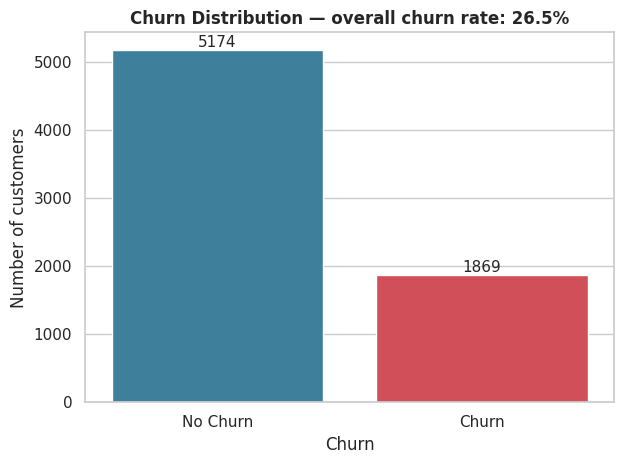

In [11]:
churn_rate = df['Churn'].mean() * 100
ax = sns.countplot(x='Churn', data=df, palette=['#2E86AB', '#E63946'])
ax.set_xticklabels(['No Churn', 'Churn'])
plt.title(f'Churn Distribution — overall churn rate: {churn_rate:.1f}%', fontweight='bold')
plt.ylabel('Number of customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('images/churn_distribution.png', dpi=150)
plt.show()

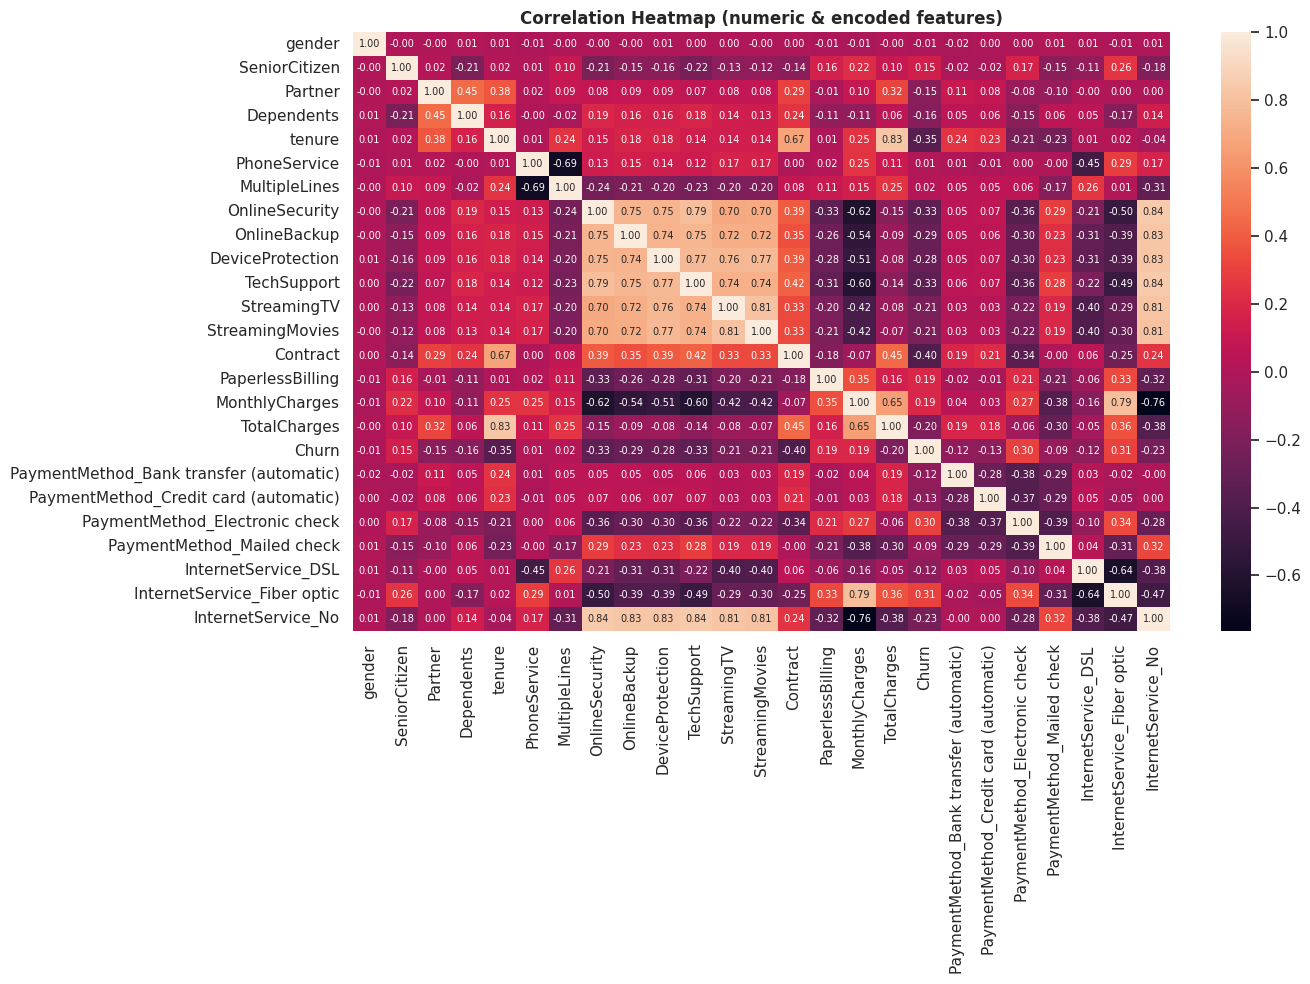

In [12]:
num_cols = list(df.select_dtypes(include='number').columns)

plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='rocket',
            annot_kws={"size": 7}, cbar=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation Heatmap (numeric & encoded features)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150)
plt.show()

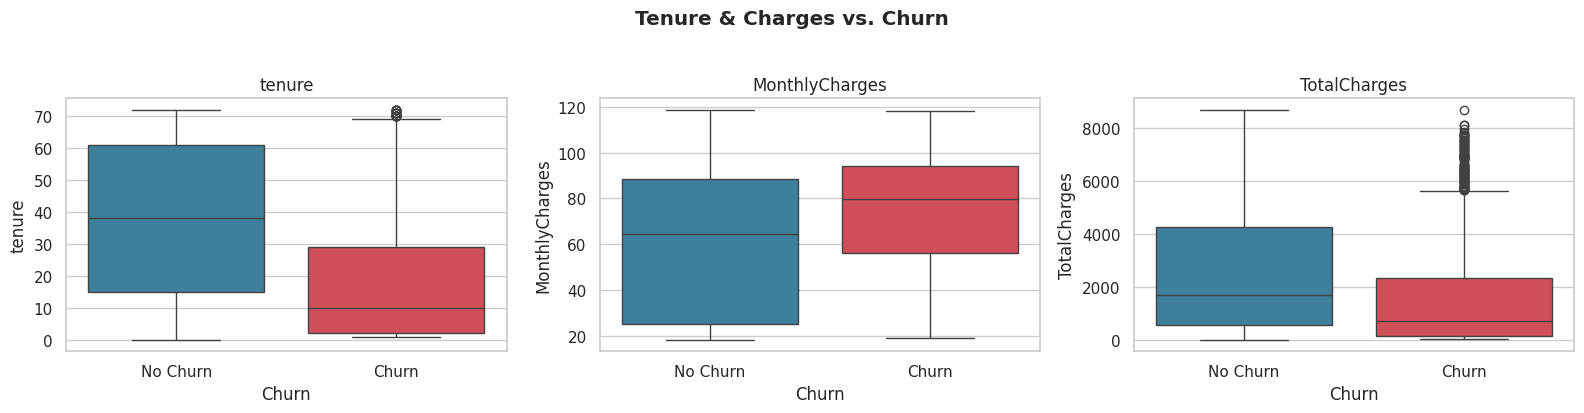

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette=['#2E86AB', '#E63946'])
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_title(col)
plt.suptitle('Tenure & Charges vs. Churn', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('images/numeric_vs_churn.png', dpi=150)
plt.show()

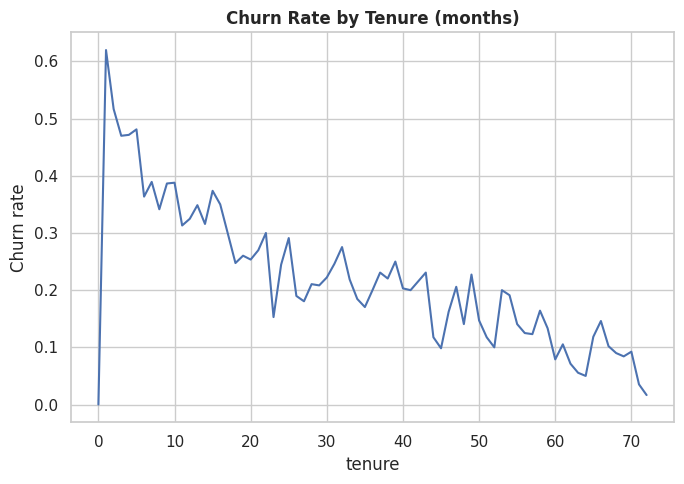

In [14]:
plt.figure(figsize=(7, 5))
sns.lineplot(data=df, x='tenure', y='Churn', errorbar=None)
plt.title('Churn Rate by Tenure (months)', fontweight='bold')
plt.ylabel('Churn rate')
plt.tight_layout()
plt.savefig('images/churn_by_tenure.png', dpi=150)
plt.show()

**Key EDA takeaways**
- Roughly **1 in 4 customers** in this dataset has churned — a meaningfully imbalanced target.
- Churn is heavily concentrated among **low-tenure customers** — churn rate drops sharply the longer a customer stays.
- Customers who churn tend to pay **higher monthly charges** and have accumulated **lower total charges** (a symptom of leaving early).
- `Contract` type and `tenure` show the strongest correlation with `Churn` among numeric features.

## 5. Feature Engineering

Build the final feature matrix `X` and target vector `y`. `gender` and `PhoneService` are dropped as they showed negligible correlation with churn during EDA.

In [15]:
y = df['Churn']
X = df.drop(columns=['Churn', 'gender', 'PhoneService', 'TotalCharges'])
print("Feature matrix shape:", X.shape)
X.columns.tolist()

Feature matrix shape: (7043, 22)


['SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'PaymentMethod_Bank transfer (automatic)',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No']

## 6. Train / Test Split & Class Balancing

We hold out 20% of the data for testing, then apply **SMOTE** (Synthetic Minority Over-sampling Technique) *only on the training set* to correct the class imbalance — this avoids leaking synthetic samples into the test set and keeps evaluation honest.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Class distribution before SMOTE (train):")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE (train):")
print(y_train.value_counts())

Class distribution before SMOTE (train):
Churn
0    4139
1    1495
Name: count, dtype: int64

Class distribution after SMOTE (train):
Churn
0    4139
1    4139
Name: count, dtype: int64


## 7. Model Training & Hyperparameter Tuning

Six classifiers are compared. Each is tuned with `RandomizedSearchCV` (5-fold cross-validation, optimizing F1-score, since churn is the minority/business-critical class).

In [17]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Adaboost': AdaBoostClassifier(random_state=RANDOM_STATE),
}

param_distributions = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000, 2000, 5000]
    },
    'Naive Bayes': {
        'var_smoothing': np.logspace(0, -9, num=100)
    },
    'KNN': {
        'n_neighbors': list(range(3, 21)),
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Decision Tree': {
        'max_depth': [None, 5, 10, 15, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'Adaboost': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.1, 0.5, 1.0]
    }
}

In [18]:
best_models = {}

for name, model in models.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[name],
        n_iter=8,
        scoring='f1',
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"  Best params: {search.best_params_}")
    print(f"  Best CV F1 score: {search.best_score_:.4f}\n")

models = best_models

Tuning Logistic Regression...


  Best params: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 2000, 'C': 0.1}
  Best CV F1 score: 0.7844

Tuning Naive Bayes...


  Best params: {'var_smoothing': np.float64(2.848035868435799e-08)}
  Best CV F1 score: 0.7799

Tuning KNN...


  Best params: {'weights': 'uniform', 'p': 1, 'n_neighbors': 3}
  Best CV F1 score: 0.8057

Tuning Decision Tree...


  Best params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
  Best CV F1 score: 0.7843

Tuning Random Forest...


  Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
  Best CV F1 score: 0.7968

Tuning Adaboost...


  Best params: {'n_estimators': 150, 'learning_rate': 0.1}
  Best CV F1 score: 0.7968



## 8. Model Evaluation

We evaluate every tuned model on the held-out test set with:
- **Accuracy** (train vs. test, to check for overfitting)
- **Precision, Recall, F1** — especially Recall on the churn class, since *missing a churner is the costly mistake*
- **ROC-AUC** — overall ranking quality
- **Confusion matrices** — the raw breakdown of correct/incorrect predictions

In [19]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_pred_train),
        'Test Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision (Churn)': precision_score(y_test, y_pred_test),
        'Recall (Churn)': recall_score(y_test, y_pred_test),
        'F1 (Churn)': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test, y_proba_test),
    })

results_df = pd.DataFrame(results).sort_values('F1 (Churn)', ascending=False).reset_index(drop=True)
results_df.style.background_gradient(cmap='Greens', subset=['F1 (Churn)', 'ROC-AUC', 'Recall (Churn)'])

,Model,Train Accuracy,Test Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
0,Adaboost,0.804180,0.748758,0.518727,0.740642,0.610132,0.829520
1,Logistic Regression,0.805750,0.753726,0.526316,0.721925,0.608794,0.820453
2,Random Forest,0.897197,0.768630,0.556075,0.636364,0.593516,0.830546
3,Decision Tree,0.817226,0.753726,0.529032,0.657754,0.586412,0.811815
4,Naive Bayes,0.751631,0.667850,0.434358,0.831551,0.570642,0.806427
5,KNN,0.894661,0.698368,0.452865,0.655080,0.535519,0.729463


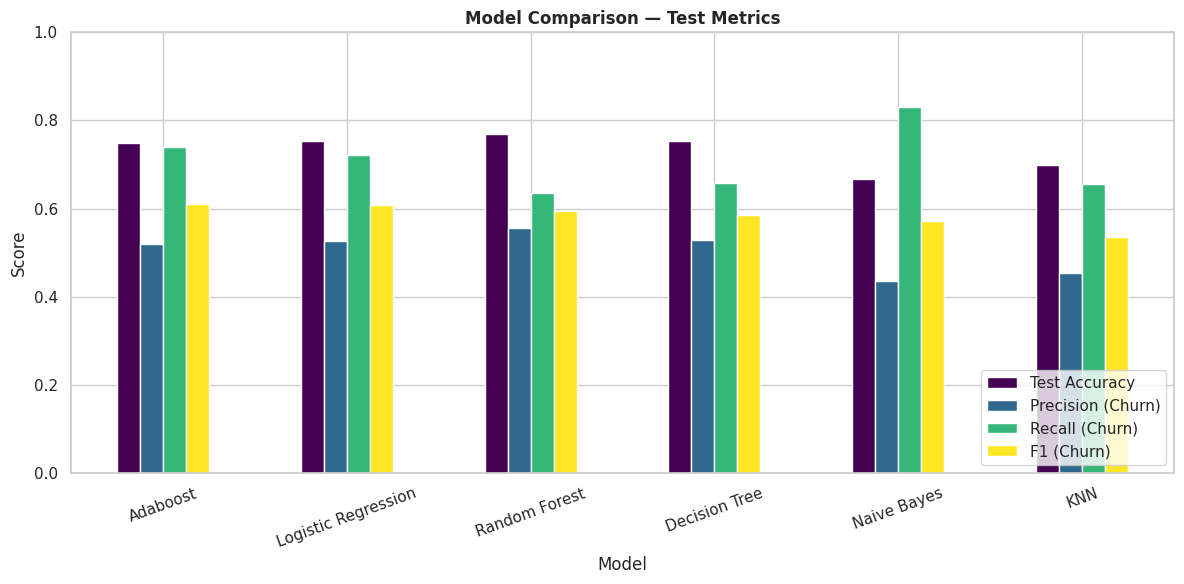

In [20]:
results_df.set_index('Model')[['Test Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1 (Churn)']] \
    .plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Comparison — Test Metrics', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150)
plt.show()

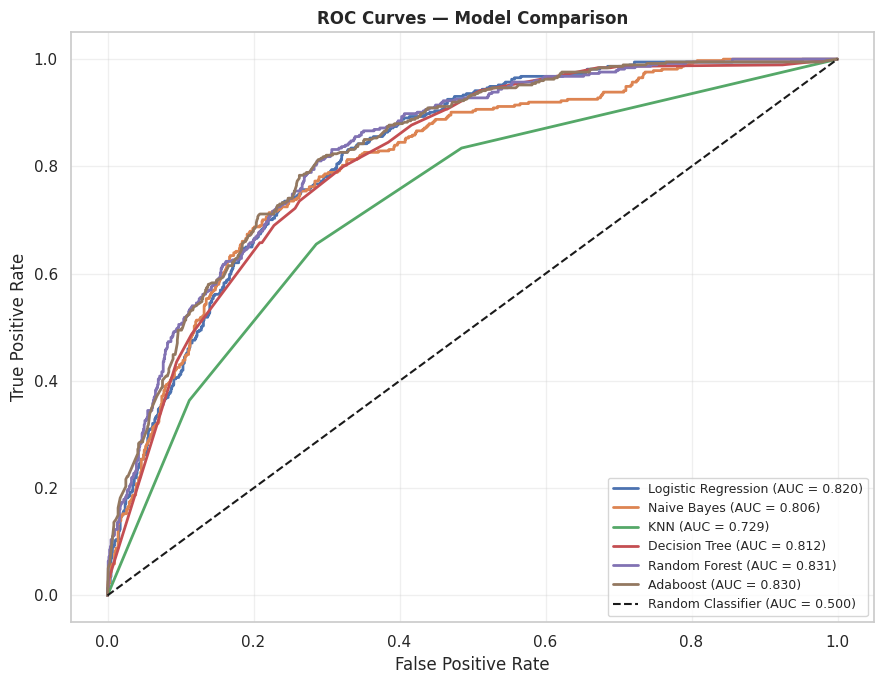

In [21]:
plt.figure(figsize=(9, 7))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/roc_curves.png', dpi=150)
plt.show()

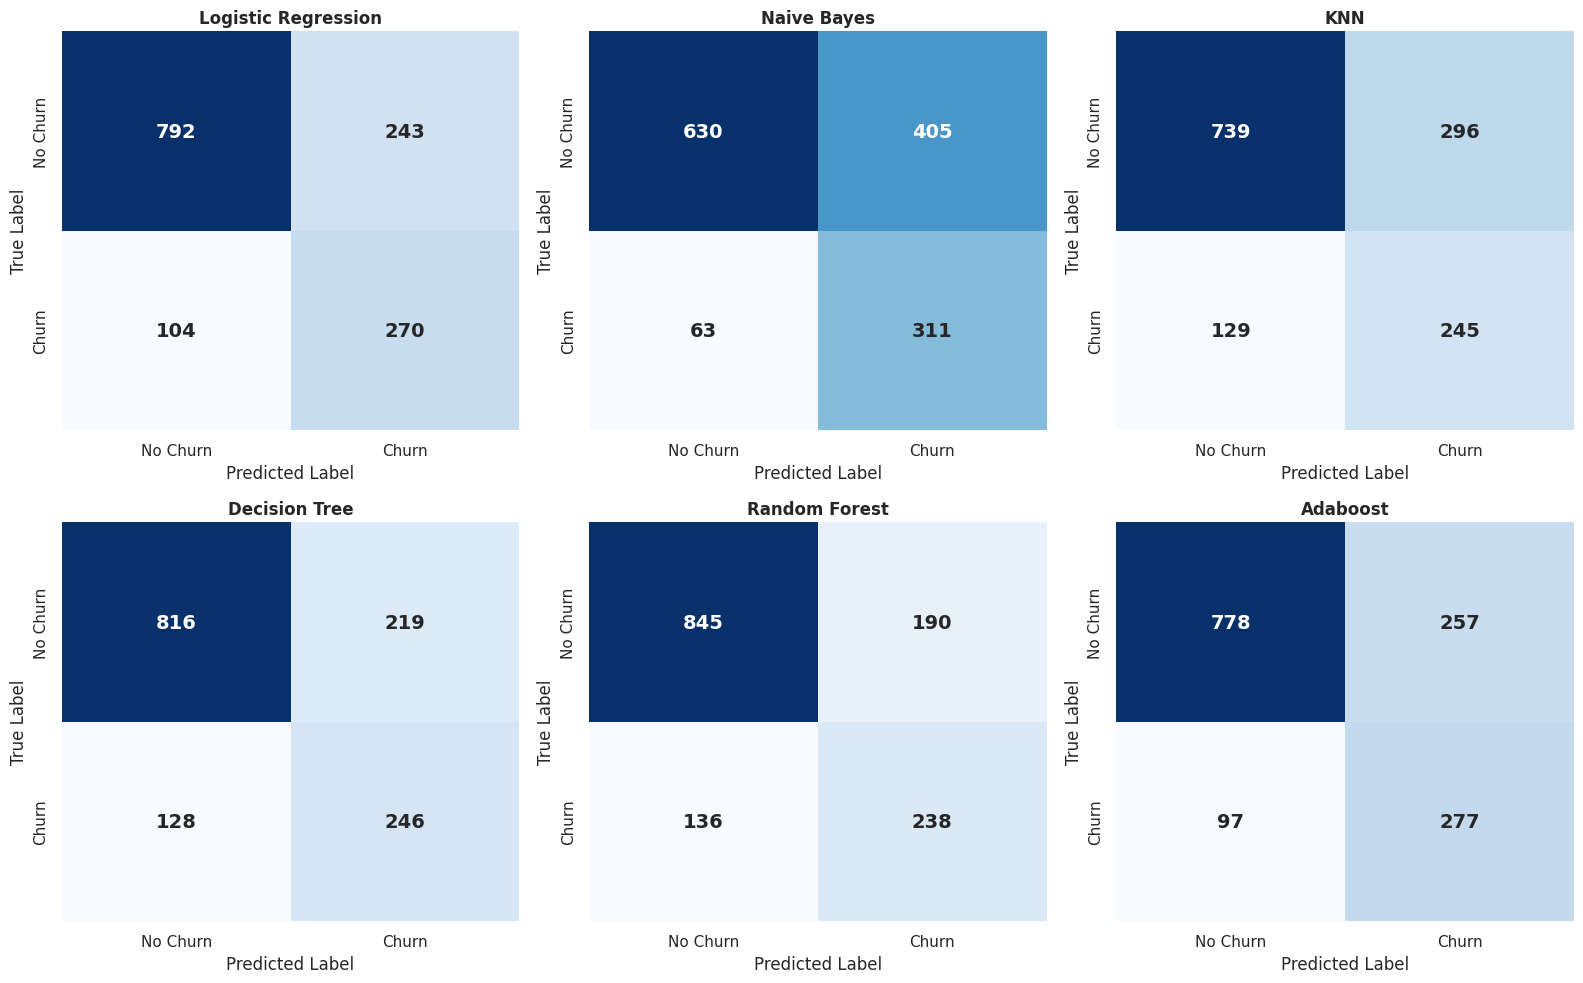

Best model by F1 (Churn class): Adaboost
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1035
       Churn       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[idx].set_title(name, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=150)
plt.show()

print("Best model by F1 (Churn class):", results_df.iloc[0]['Model'])
print(classification_report(y_test, models[results_df.iloc[0]['Model']].predict(X_test),
                             target_names=['No Churn', 'Churn']))

## 9. Feature Importance

Using the tuned **Random Forest**, we rank features by their contribution to predicting churn.

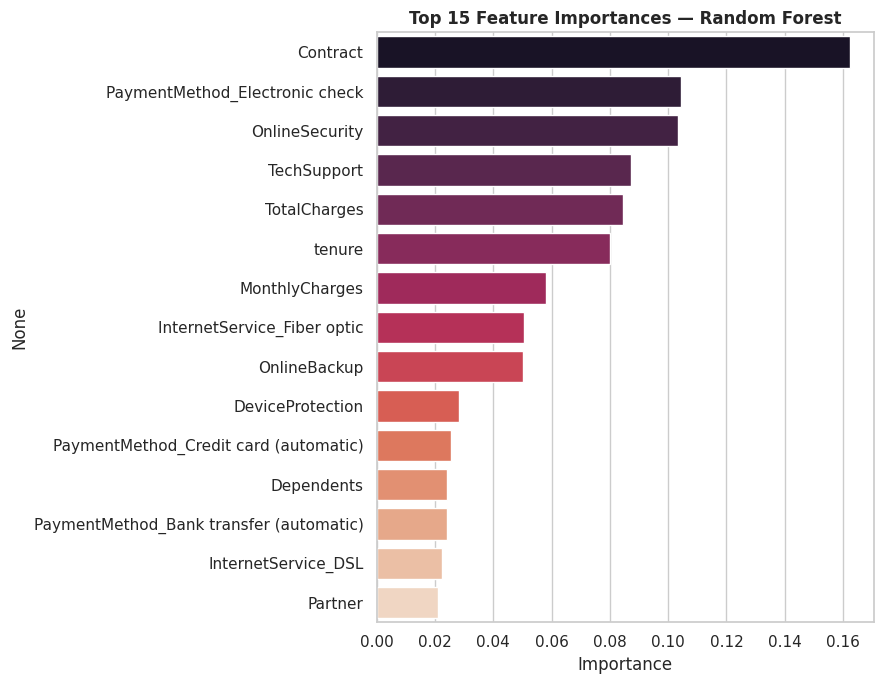

In [23]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index, palette='rocket')
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150)
plt.show()

## 10. Conclusions & Business Recommendations

**Modeling summary**
- All six models were trained on SMOTE-balanced data and evaluated on an untouched, stratified test set.
- The best-performing model (see the table in Section 8) offers the strongest trade-off between catching churners (Recall) and avoiding false alarms (Precision).
- Tree-based ensembles (Random Forest / Adaboost) tend to give the best ranking quality (ROC-AUC) and the clearest feature-importance signal.

**Top churn drivers observed**
- **Contract type** — month-to-month customers churn far more than those on 1- or 2-year contracts.
- **Tenure** — churn risk is highest in the first few months of the relationship.
- **Monthly charges / internet service type** — customers on pricier plans (e.g., Fiber optic) show elevated churn.
- **Lack of add-on services** (Online Security, Tech Support) correlates with higher churn — these may act as "stickiness" features.

**Recommended actions**
1. Prioritize retention outreach for **new, month-to-month customers** in their first 90 days.
2. Offer **incentives to move to longer-term contracts** (discounts for 1-/2-year commitments).
3. Bundle **Online Security / Tech Support** into onboarding packages to increase stickiness.
4. Use the trained model's churn-probability score to build a **proactive "at-risk customer" watchlist** for the retention team.

---
*This notebook is for educational / portfolio purposes. Metrics will vary slightly across runs due to the randomized hyperparameter search.*